Loaded and validated config from configs/GK2A/FLaTO.yaml: {'task': 'segmentation', 'model_name': 'FLaTO', 'weights': None, 'transfer_weights': 'results/IwDA/FLaTO_best.pth', 'load_mode': 'best', 'learning_rate': 0.001, 'batch_size': 16, 'num_workers': 4, 'patience': 50, 'delta': 0.005, 'loss': 'ce', 'loss_weights': None, 'num_epochs': 500, 'model_save_dir': './results/GK2A', 'metrics': ['mIoU', 'precision', 'recall', 'f1_score'], 'export': False, 'conf_threshold': None, 'img_size': 224, 'num_classes': 2, 'in_channels': 3, 'datasets': [{'name': 'IWFullSceneDataset', 'train_paths': ['datasets/GK2A/GK2A_5shot/train'], 'test_paths': ['datasets/GK2A/GK2A_5shot/test']}]}
Loaded custom model 'FLaTO' from 'models/FLaTO.py'.
Loading model from results/GK2A/FLaTO_best.pth
Model successfully loaded from results/GK2A/FLaTO_best.pth, epoch: 29.
Displaying image: datasets/GK2A/fullscreen/_20200411043.png


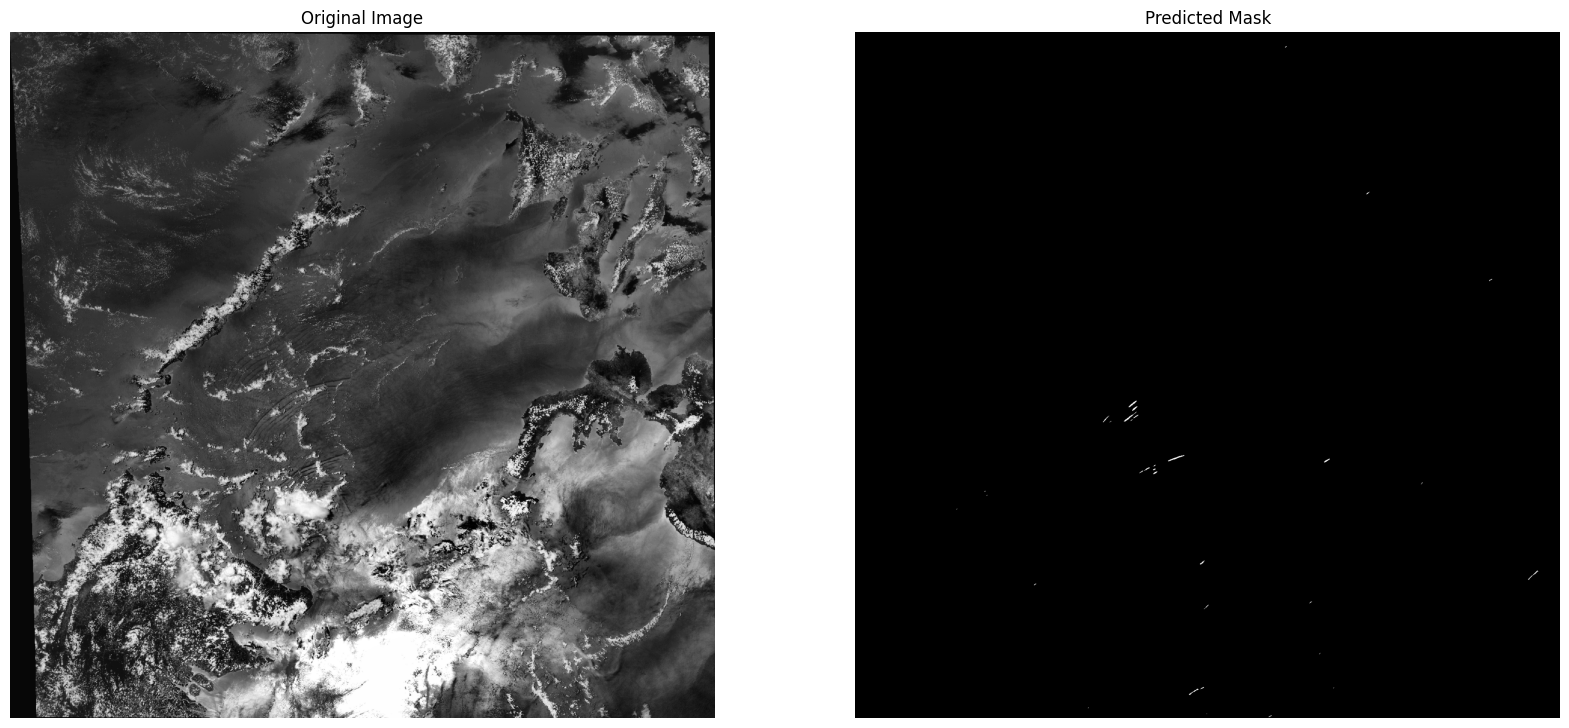

Displaying image: datasets/GK2A/fullscreen/_20200312043.png


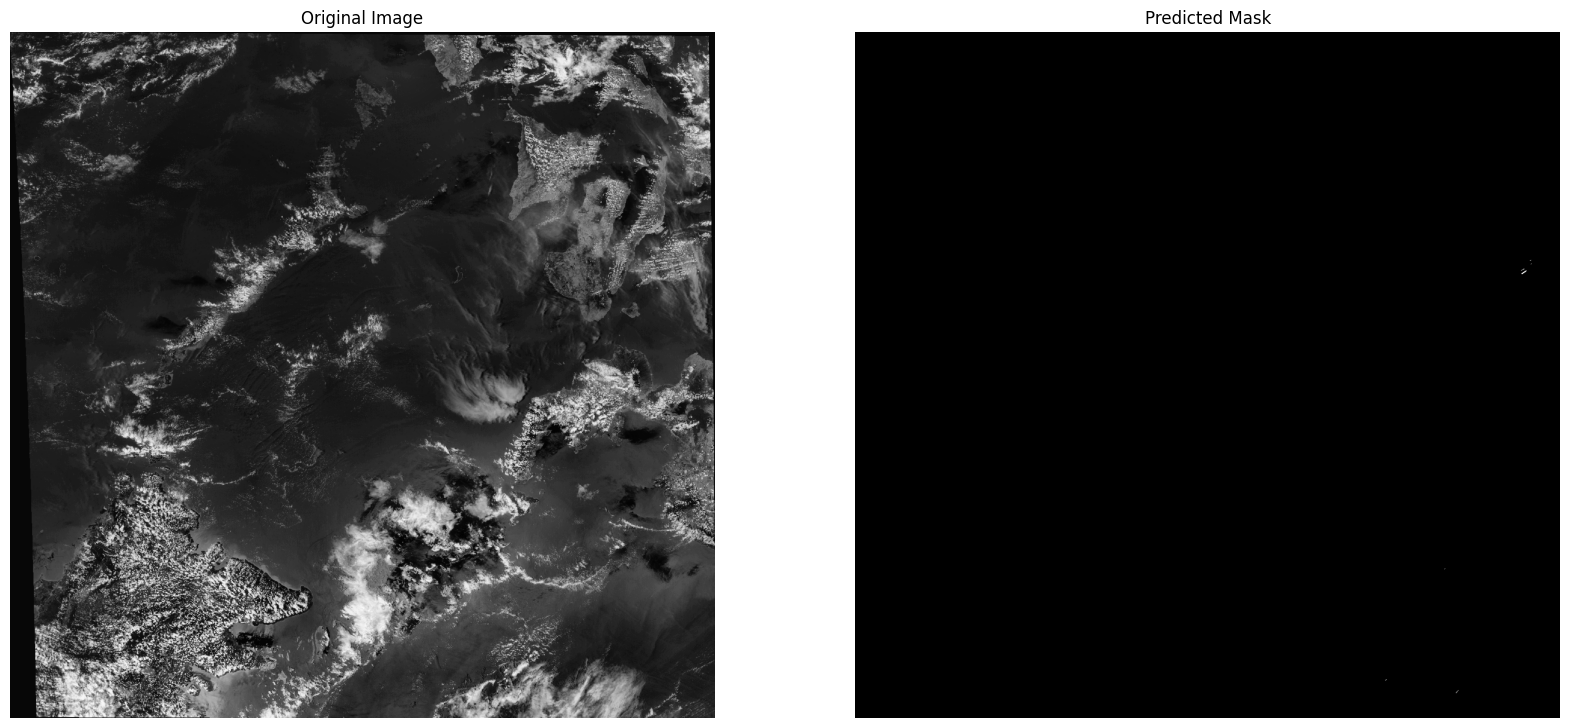

Displaying image: datasets/GK2A/fullscreen/_20210524050.png


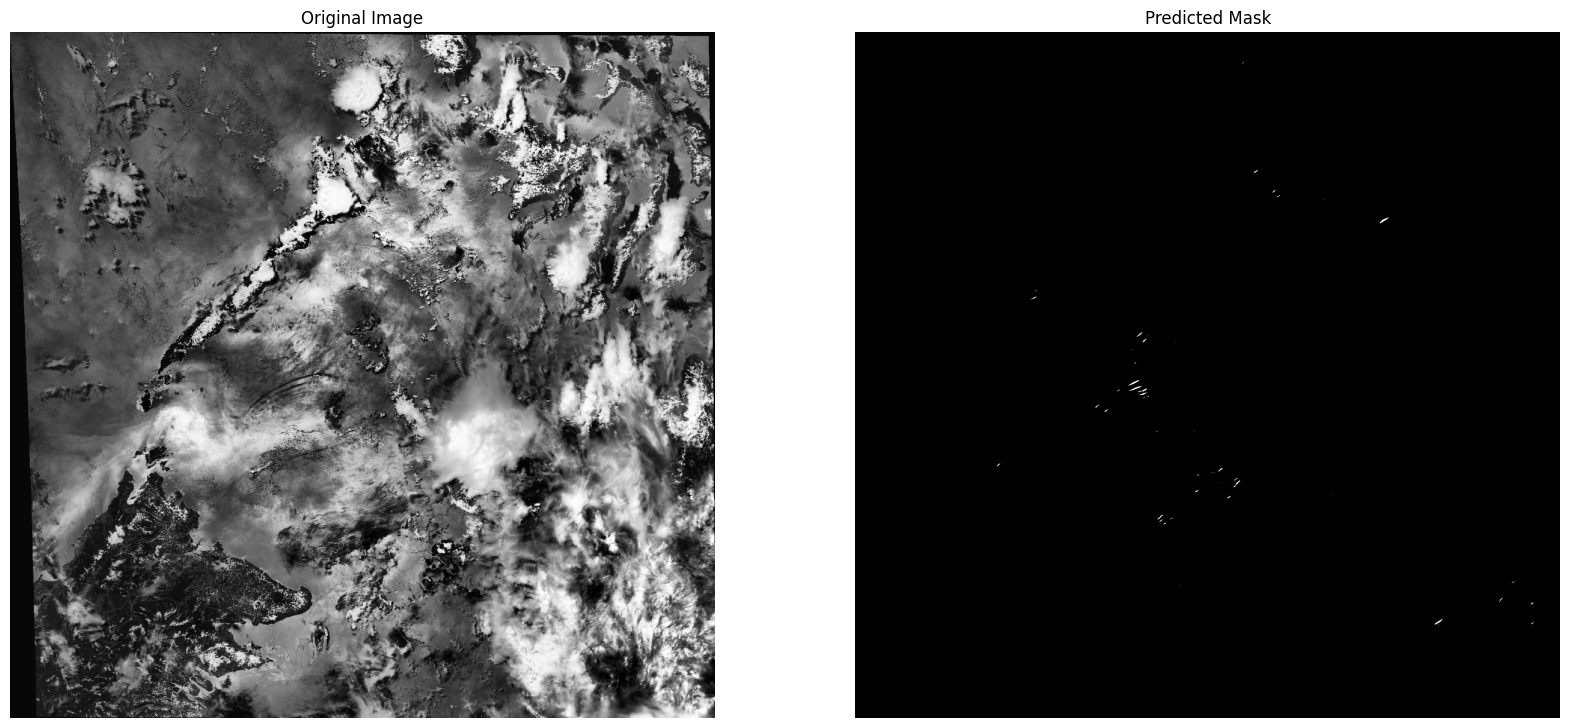

In [4]:
import os
import sys
import torch
import numpy as np
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import dancher_tools as dt
import random

module_path = '/home/dancher/Projects/TWIC-Net'
sys.path.append(module_path)  # 添加指定路径

def cut_image(image, crop_size=224):
    width, height = image.size
    blocks = []
    positions = []

    for y in range(0, height, crop_size):
        for x in range(0, width, crop_size):
            x_end = min(x + crop_size, width)
            y_end = min(y + crop_size, height)
            block = image.crop((x, y, x_end, y_end)).resize((crop_size, crop_size), Image.LANCZOS)
            blocks.append(block)
            positions.append((x, y, x_end - x, y_end - y))

    return blocks, positions

def assemble_image(blocks, positions, original_size):
    full_mask = np.zeros(original_size, dtype=np.uint8)
    for block, (x, y, w, h) in zip(blocks, positions):
        block = np.array(block.resize((w, h), Image.NEAREST))
        full_mask[y:y + h, x:x + w] = block
    return full_mask

def predict_block(block, model, device):
    model.eval()
    with torch.no_grad():
        transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        image_tensor = transform(block).unsqueeze(0).to(device)
        logits = model(image_tensor)
        pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()
        return Image.fromarray((pred_mask * 255).astype(np.uint8))

def predict_and_reassemble(image_path, model, device, save_dir, show=False, export=True):
    image = Image.open(image_path).convert('RGB')
    original_size = image.size[::-1]
    blocks, positions = cut_image(image)
    pred_blocks = [predict_block(block, model, device) for block in blocks]
    full_mask = assemble_image(pred_blocks, positions, original_size)

    if export:
        # 保存预测结果
        base_name = os.path.basename(image_path)
        save_path = os.path.join(save_dir, f"{os.path.splitext(base_name)[0]}.png")
        Image.fromarray(full_mask).save(save_path)
        print(f"Saved predicted mask to: {save_path}")

    if show:
        # 展示原始图像和预测掩码，增加图像显示大小
        plt.figure(figsize=(20, 10))  # 增大figsize的值，单位为英寸
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(full_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')
        plt.show()

def main(input_path, show=False, export=True):
    args = dt.utils.get_config('configs/GK2A/FLaTO.yaml')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    args.weights = 'results/GK2A/FLaTO_best.pth'
    model = dt.utils.get_model(args, device)
    model.load(model_dir=args.model_save_dir, mode=args.load_mode, specified_path=args.weights)

    # 确定输出文件夹
    save_dir = 'predictions'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    if os.path.isfile(input_path):
        # 如果是单个图像文件
        print(f"Processing single image: {input_path}")
        predict_and_reassemble(input_path, model, device, save_dir, show=show, export=export)
    elif os.path.isdir(input_path):
        # 如果是一个文件夹
        image_files = [f for f in os.listdir(input_path) if f.endswith(('.png', '.jpg'))]
        if export:
            # 导出所有文件
            for file_name in image_files:
                image_path = os.path.join(input_path, file_name)
                print(f"Exporting image: {image_path}")
                predict_and_reassemble(image_path, model, device, save_dir, show=False, export=True)

        if show:
            # 随机抽取3个文件进行展示
            sample_files = random.sample(image_files, min(3, len(image_files)))
            for file_name in sample_files:
                image_path = os.path.join(input_path, file_name)
                print(f"Displaying image: {image_path}")
                predict_and_reassemble(image_path, model, device, save_dir, show=True, export=False)
    else:
        print(f"Invalid input path: {input_path}")

if __name__ == '__main__':
    # 输入路径：可以是单个图像文件或包含图像的文件夹
    input_path = 'datasets/GK2A/fullscreen'  # 或者 'path/to/your/image.jpg'
    show_results = True  # 设置为 True 以显示随机3个样本的预测结果
    export_results = False  # 设置为 True 以导出所有预测结果
    main(input_path, show=show_results, export=export_results)
